In [27]:
from lab.moons.data import create_moon_data


nb_batches = 300
batch_size = 2

dataset_name = f"test_base_params_{nb_batches}_points_linear_075_noise_025"

X, Y = create_moon_data(n_samples=nb_batches, noise=0.25)
X[:, 1] += 0.75
X.shape, Y.shape


((300, 2), (300, 1))

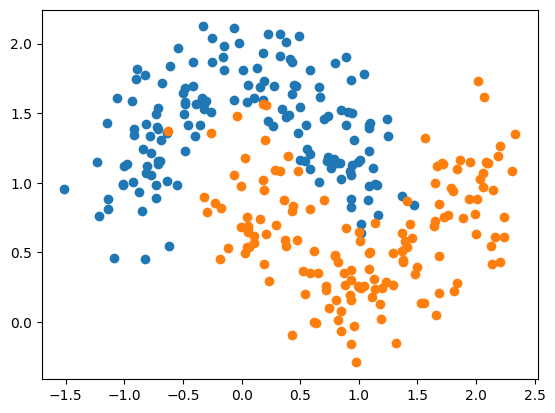

In [28]:
import matplotlib.pyplot as plt

mask0 = (Y == 0).ravel()
mask1 = (Y == 1).ravel()
plt.scatter(X[mask0, 0], X[mask0, 1])
plt.scatter(X[mask1, 0], X[mask1, 1])

In [29]:
from quantum_simulation.configs import jpc_config_dudas, quantum_parameters_dudas, base_encoding

jpc_config = jpc_config_dudas
quantum_parameters = quantum_parameters_dudas
encoding = base_encoding


In [30]:
from quantum_simulation import Simulator

simulator = Simulator(jpc_config=jpc_config,
                      encoding=encoding)


In [31]:
from quantum_learn import build_f

build_f_quad = build_f.BuildFQuadratures(jpc_config=jpc_config_dudas)
build_f_quad_poly = build_f.BuildFQuadraturesPolynomials(jpc_config=jpc_config_dudas)
build_f_probas = build_f.BuildFProbas(jpc_config=jpc_config_dudas, clip_probas=2)



In [32]:
import numpy as np

F_quad = np.empty((nb_batches, batch_size * build_f_quad.output_dim))
F_quad_poly = np.empty((nb_batches, batch_size * build_f_quad_poly.output_dim))
F_probas = np.empty((nb_batches, batch_size * build_f_probas.output_dim))
F_quad.shape


(300, 80)

In [33]:
for i, x in enumerate(X):
    results = simulator.run_simulation(X=x, quantum_parameters_list=[quantum_parameters])[0]
    F_quad[i, :] = build_f_quad(results).reshape(-1)
    F_quad_poly[i, :] = build_f_quad_poly(results).reshape(-1)
    F_probas[i, :] = build_f_probas(results).reshape(-1)

|██████████| 100.0% ◆ elapsed 2.84s ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 2.34s ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 2.82s ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 2.13s ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 2.28s ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 2.56s ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 2.05s ◆ remaining 0.00ms     
|██████████| 100.0% ◆ elapsed 2.17s ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 2.04s ◆ remaining 0.00ms     
|██████████| 100.0% ◆ elapsed 2.26s ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 2.50s ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 2.40s ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 2.31s ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 2.32s ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 2.67s ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 2.39s ◆ remaining 0.00ms  
|██████████| 100.0% ◆ elapsed 2.48s ◆ remaining 0.00ms  
|██████████| 100.0% ◆ ela

In [34]:
import numpy as np
from pathlib import Path

save_dir = Path("../datasets") / dataset_name

save_dir.mkdir(parents=True, exist_ok=True)

jpc_config.save(save_dir / "jpc_config.txt")
quantum_parameters.save(save_dir / "quantum_parameters.txt")
encoding.save(save_dir / "encoding.txt")

np.save(save_dir / "X.npy", X)
np.save(save_dir / "Y.npy", Y)
np.save(save_dir / "f_quad.npy", F_quad)
np.save(save_dir / "f_quad_poly.npy", F_quad_poly)
np.save(save_dir / "f_probas.npy", F_probas)


